In [ ]:
import pandas as pd

df = pd.read_csv("order_history_kaggle_data.csv")

df.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


In [ ]:
# Dataset Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 29 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Restaurant ID                                       21321 non-null  int64  
 1   Restaurant name                                     21321 non-null  object 
 2   Subzone                                             21321 non-null  object 
 3   City                                                21321 non-null  object 
 4   Order ID                                            21321 non-null  int64  
 5   Order Placed At                                     21321 non-null  object 
 6   Order Status                                        21321 non-null  object 
 7   Delivery                                            21321 non-null  object 
 8   Distance                                            21321 non-null  object 


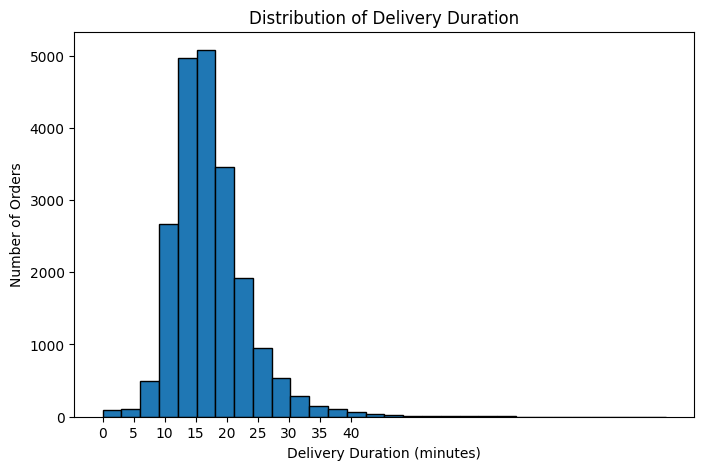

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

plt.hist(df['KPT duration (minutes)'],
         bins=30,
         edgecolor='black')

plt.title('Distribution of Delivery Duration')
plt.xlabel('Delivery Duration (minutes)')
plt.ylabel('Number of Orders')

# Set x-axis every 5 minutes
plt.xticks(np.arange(0, 45, 5))

plt.show()

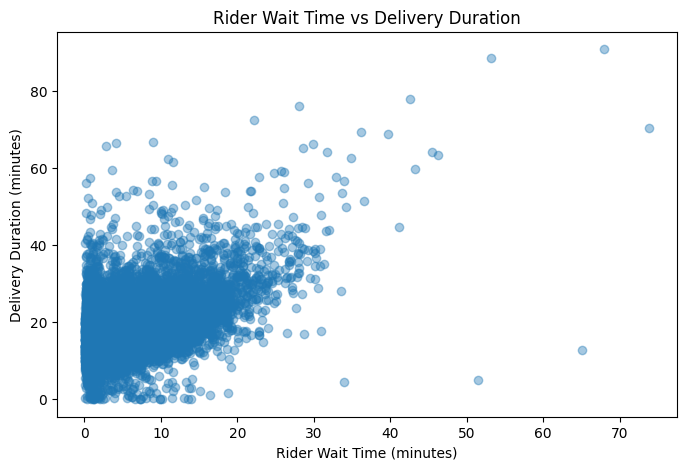

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Rider wait time (minutes)'],
            df['KPT duration (minutes)'],
            alpha=0.4)

plt.title('Rider Wait Time vs Delivery Duration')
plt.xlabel('Rider Wait Time (minutes)')
plt.ylabel('Delivery Duration (minutes)')
plt.show()

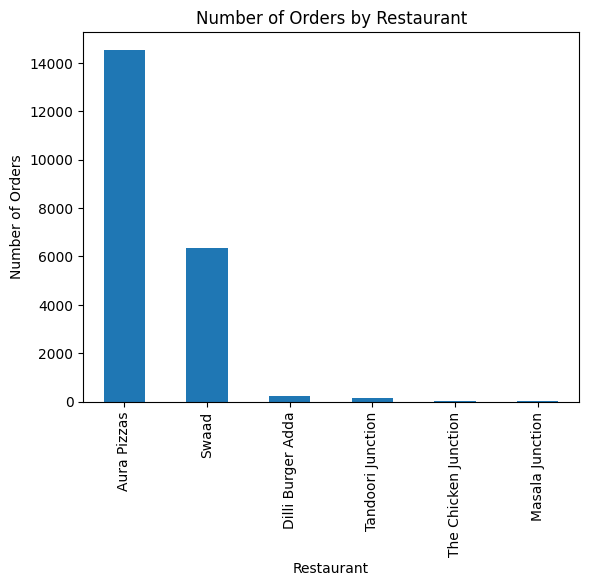

In [ ]:
restaurant_counts = df['Restaurant name'].value_counts()

restaurant_counts.plot(kind='bar')

plt.title('Number of Orders by Restaurant')
plt.xlabel('Restaurant')
plt.ylabel('Number of Orders')

plt.show()

In [ ]:
# Check missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
Instructions,20601
Discount construct,5498
Rating,18830
Review,21025
Cancellation / Rejection reason,21135
Restaurant compensation (Cancellation),21188
Restaurant penalty (Rejection),21318
KPT duration (minutes),295
Rider wait time (minutes),168
Customer complaint tag,20852


In [ ]:
# Check duplicate records
duplicate_records = df.duplicated().sum()

print("Number of duplicate records:", duplicate_records)

Number of duplicate records: 0


In [ ]:
df["KPT duration (minutes)"].describe(percentiles=[0.25, 0.5, 0.75, 0.9])

,KPT duration (minutes)
count,21026.000000
mean,17.332960
std,6.283388
min,0.000000
25%,13.380000
50%,16.330000
75%,20.050000
90%,24.550000
max,90.870000


In [ ]:
df["Delivery_Status"] = df["KPT duration (minutes)"].apply(
    lambda x: "Late" if x > 30 else "On Time"
)

df[["KPT duration (minutes)", "Delivery_Status"]].head()

,KPT duration (minutes),Delivery_Status
0,18.35,On Time
1,16.95,On Time
2,14.05,On Time
3,19.00,On Time
4,15.97,On Time


In [ ]:
df["Delivery_Status"].value_counts()

,count
Delivery_Status,
On Time,20534
Late,787


In [ ]:
df["Delivery_Status_Encoded"] = df["Delivery_Status"].map({
    "On Time": 0,
    "Late": 1
})

df[["Delivery_Status", "Delivery_Status_Encoded"]].head()

,Delivery_Status,Delivery_Status_Encoded
0,On Time,0
1,On Time,0
2,On Time,0
3,On Time,0
4,On Time,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = ["Restaurant name", "City", "Delivery", "Order Status", "Order Ready Marked"]

encoder = LabelEncoder()

for col in categorical_columns:
    df[col + "_Encoded"] = encoder.fit_transform(df[col].astype(str))

df[[col + "_Encoded" for col in categorical_columns]].head()

,Restaurant name_Encoded,City_Encoded,Delivery_Encoded,Order Status_Encoded,Order Ready Marked_Encoded
0,3,0,0,0,0
1,3,0,0,0,0
2,3,0,0,0,0
3,3,0,0,0,0
4,3,0,0,0,0


In [ ]:
# create model data
features = [
    "Restaurant name_Encoded",
    "City_Encoded",
    "Delivery_Encoded",
    "Order Status_Encoded",
    "Order Ready Marked_Encoded",
    "Rider wait time (minutes)",
    "Delivery_Status_Encoded"
]

model_data = df[features].dropna()

X = model_data.drop("Delivery_Status_Encoded", axis=1)
y = model_data["Delivery_Status_Encoded"]

In [ ]:
# Split Features and Target
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train baseline Decision Tree
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9626565823682345

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      4074
           1       0.49      0.12      0.19       157

    accuracy                           0.96      4231
   macro avg       0.73      0.56      0.59      4231
weighted avg       0.95      0.96      0.95      4231


Confusion Matrix:
[[4054   20]
 [ 138   19]]


In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Improved model: Random Forest with class balancing
improved_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

improved_model.fit(X_train, y_train)

# Prediction
y_pred_improved = improved_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_improved))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_improved))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_improved))

Accuracy: 0.8773339636019853

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      4074
           1       0.13      0.39      0.19       157

    accuracy                           0.88      4231
   macro avg       0.55      0.64      0.56      4231
weighted avg       0.94      0.88      0.91      4231


Confusion Matrix:
[[3651  423]
 [  96   61]]


In [ ]:
# Automated validation script for missing values

missing_values = df.isnull().sum().sum()

print("========== DATA VALIDATION REPORT ==========")

if missing_values == 0:
    print("Status : PASSED")
    print("Message: No missing values detected.")
else:
    print("Status : FAILED")
    print(f"Message: {missing_values} missing values detected.")

========== DATA VALIDATION REPORT ==========
Status : FAILED
Message: 150910 missing values detected.
